In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer


In [3]:
# Load data
df = pd.read_csv("./data/raw_data.csv")

# Drop rows with null values
df = df.dropna()

# Data Preprocessing

In [4]:
cols_to_drop = [
    'EmployeeCount', 'EmployeeNumber',
    'Over18', 'StandardHours', 'HowToEmploy', 'Incentive', 'Years', 'Year'
]

df = df.drop(columns=cols_to_drop, errors='ignore')


In [5]:
target = 'StressRating'
y = df[target]
X = df.drop(columns=[target])

In [6]:
categorical_cols_to_encode = [
    'Attrition', 'BusinessTravel', 'Department', 'EducationField',
    'Gender', 'JobRole', 'MaritalStatus'
]

In [7]:
# Label encode categoricals
X_encoded = X.copy()
for col in categorical_cols_to_encode:
    if col in X_encoded.columns:
        le = LabelEncoder()
        X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

# StandardScaler on ALL columns (everything is numeric after encoding)
scaler = StandardScaler()
X_normalized = pd.DataFrame(scaler.fit_transform(X_encoded), columns=X_encoded.columns)

In [8]:

# Add target back WITHOUT scaling (StressRating 1-5 is already interpretable)
processed_data = X_normalized.copy()
processed_data[target] = y.values
processed_data = processed_data.replace([np.inf, -np.inf], np.nan).dropna()
processed_data.to_csv('./data/processed_data.csv', index=False)

print(f"✓ Processed data saved — shape: {processed_data.shape}")
print(f"  Features scaled, target ({target}) kept in original 1-5 scale.")
print(processed_data.describe().loc[['mean', 'std']].round(4))


✓ Processed data saved — shape: (1470, 37)
  Features scaled, target (StressRating) kept in original 1-5 scale.
         Age  Attrition  BusinessTravel  Department  DistanceFromHome  \
mean  0.0000    -0.0000         -0.0000     -0.0000            0.0000   
std   1.0003     1.0003          1.0003      1.0003            1.0003   

      Education  EducationField  EnvironmentSatisfaction  Gender  \
mean     0.0000          0.0000                   0.0000 -0.0000   
std      1.0003          1.0003                   1.0003  1.0003   

      PerformanceIndex  ...  YearsWithCurrManager  RemoteWork  MonthlyIncome  \
mean            0.0000  ...                0.0000     -0.0000         0.0000   
std             1.0003  ...                1.0003      1.0003         1.0003   

      WelfareBenefits  InHouseFacility  ExternalFacility  ExtendedLeave  \
mean           0.0000           0.0000            0.0000        -0.0000   
std            1.0003           1.0003            1.0003         1.0003 

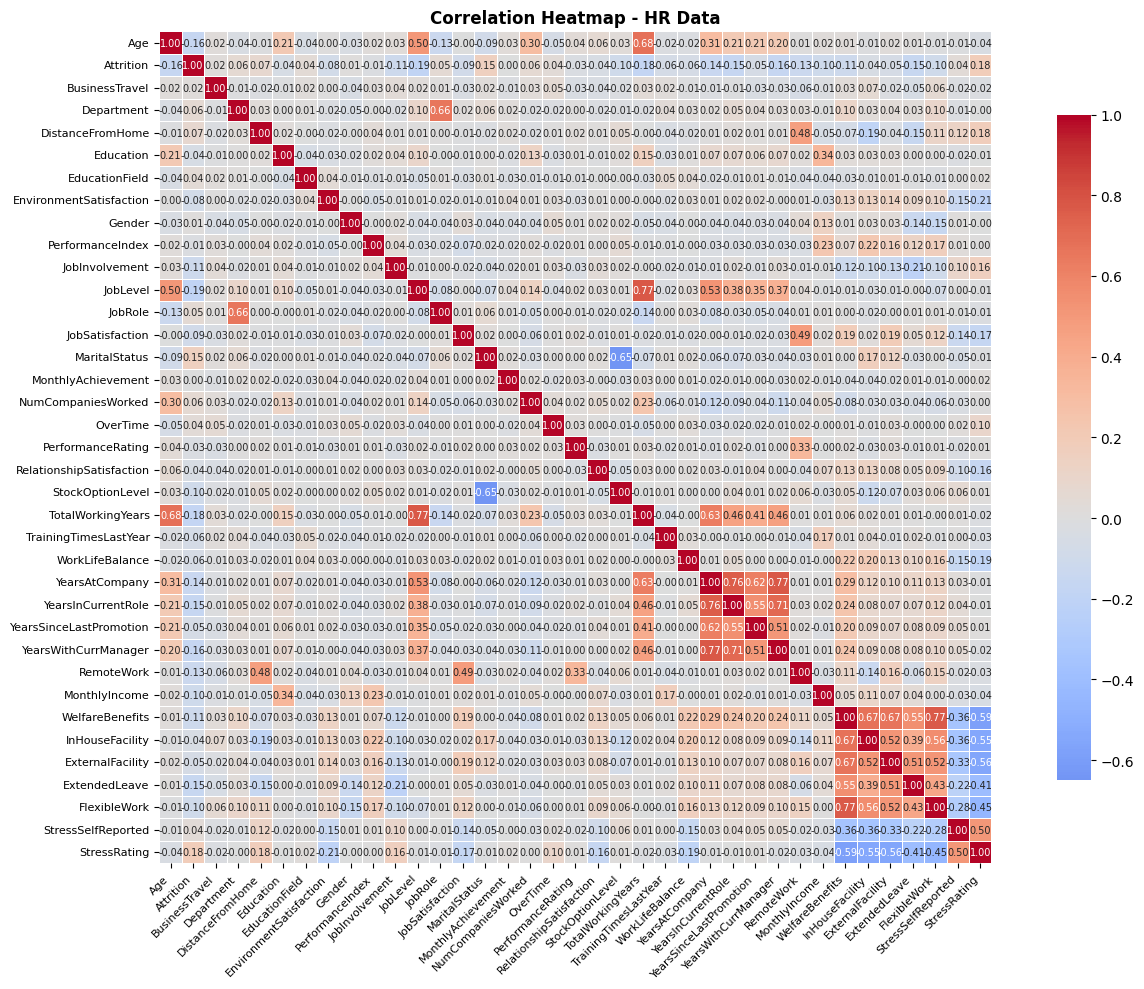

✓ Correlation heatmap created with 37 features


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create correlation matrix
correlation_matrix = processed_data.corr()

# Create heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 7}, xticklabels=True, yticklabels=True)
plt.title('Correlation Heatmap - HR Data', fontsize=12, fontweight='bold')
plt.xticks(fontsize=8, rotation=45, ha='right')
plt.yticks(fontsize=8, rotation=0)
plt.tight_layout()
plt.show()

print(f"✓ Correlation heatmap created with {len(correlation_matrix)} features")